## Ankle RSU series - mechanism

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def Rx(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1, 0, 0],
        [0, c, -s],
        [0, s,  c]
    ])
def Ry(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0,  s],
        [ 0, 1,  0],
        [-s, 0,  c]
    ])

l_fixed = 10.0
lbar = 75.0    
lrod1 = 246.65
lrod2 = 148.21     
lspacing_1 = 60.0  
lspacing_2 = 60.0

O = np.array([0.0, 0.0, 0.0])

rA1 = np.array([ lspacing_1/2.0, l_fixed, 260.0])
rA2 = np.array([-lspacing_1/2.0, l_fixed, 160.0])

rB1_H = np.array([ lspacing_2/2.0, 80.48, 234.35])
rB2_H = np.array([-lspacing_2/2.0, 80.48, 134.35])

rC1_H = np.array([ lspacing_2/2.0, 46.89, -l_fixed])
rC2_H = np.array([-lspacing_2/2.0, 46.89, -l_fixed])

rD1_H = np.array([ lspacing_1/2.0, -100.0, -l_fixed])
rD2_H = np.array([-lspacing_1/2.0, -100.0, -l_fixed])

S1 = np.array([-lspacing_1/2.0, 10.0, 260.0])
S2 = np.array([ -lspacing_1/2.0, 0.0, 0.0])
S4 = np.array([  lspacing_1/2.0, 0.0, 0.0])

axis = np.array([1.0, 0.0, 0.0])

def solve_theta_general(rC, rA, rB_home, lrod, axis):
    v = rC - rA
    d = rB_home - rA
    RHS = 0.5 * (np.dot(v,v) + np.dot(d,d) - lrod**2)

    u = axis / np.linalg.norm(axis)
    d_par = u * np.dot(u, d)
    d_perp = d - d_par

    a = np.dot(v, d_perp)
    b = np.dot(v, np.cross(u, d))
    C = RHS - np.dot(v, d_par)

    D = a*a + b*b
    disc = b*b*C*C - D*(C*C - a*a)
    if disc < 0:
        return []

    root = np.sqrt(disc)
    sols = []
    for s in [(b*C + root)/D, (b*C - root)/D]:
        if abs(s) <= 1:
            c = (C - b*s) / a
            sols.append(np.arctan2(s, c))
    return sols
def set_equal_aspect(ax, pts):
    P = np.array(list(pts.values()))
    mid = P.mean(axis=0)
    r = (P.max(axis=0) - P.min(axis=0)).max() / 2
    ax.set_xlim(mid[0]-r, mid[0]+r)
    ax.set_ylim(mid[1]-r, mid[1]+r)
    ax.set_zlim(mid[2]-r, mid[2]+r)
def plot_plane(ax, p1, p2, p3, p4, color, alpha=0.4):
    ax.add_collection3d(
        Poly3DCollection([[p1,p2,p3,p4]], facecolor=color, alpha=alpha)
    )
def visualize(points):
    fig = plt.figure(figsize=(15,5))
    fig.canvas.manager.set_window_title("Ankle RSU mech - series")

    def plot_mechanism(ax):

        # --- Points (same colors as parent code) ---
        point_colors = {
            "O":"r","A1":"r","A2":"r",
            "B1":"b","B2":"b","C1":"b","C2":"b","D1":"b","D2":"b",
            "B1H":"r","B2H":"r","C1H":"r","C2H":"r","D1H":"r","D2H":"r"
        }

        for k,c in point_colors.items():
            ax.scatter(*points[k], c=c, s=30)

        # --- Links ---
        links = [("A1","B1"),("A2","B2"),
                 ("B1","C1"),("B2","C2"),
                 ("C1","C2"),("C1","D1"),
                 ("C2","D2"),("D1","D2")]

        fixed = [("S1","S2"),("S2","S4"),("S4","A1"),("A1","S1")]

        home = [("A1","B1H"),("A2","B2H"),
                ("B1H","C1H"),("B2H","C2H"),
                ("C1H","C2H"),("C1H","D1H"),
                ("C2H","D2H"),("D1H","D2H")]

        for p,q in links:
            ax.plot(*zip(points[p], points[q]), 'k-', lw=2)

        for p,q in fixed:
            ax.plot(*zip(points[p], points[q]), 'b-', lw=2)

        for p,q in home:
            ax.plot(*zip(points[p], points[q]), 'g--', lw=2)

        ax.set_proj_type('ortho')
        set_equal_aspect(ax, points)

    # --- Views (same as parent code) ---
    ax1 = fig.add_subplot(132, projection='3d')
    plot_mechanism(ax1)
    ax1.view_init(20, -45)

    ax2 = fig.add_subplot(131, projection='3d')
    plot_mechanism(ax2)
    ax2.view_init(0, 90)

    ax3 = fig.add_subplot(133, projection='3d')
    plot_mechanism(ax3)
    ax3.view_init(0, 0)

    ax1.set_xlabel("x axis")
    ax1.set_ylabel("y axis")
    ax1.set_zlabel("z axis")

    # --- Planes ---
    plot_plane(ax1, points["S1"], points["S2"], points["S4"], points["A1"],
               color='cyan', alpha=0.5)
    plot_plane(ax1, points["D1"], points["C1"], points["C2"], points["D2"],
               color='yellow', alpha=0.5)

    plot_plane(ax2, points["S1"], points["S2"], points["S4"], points["A1"],
               color='cyan', alpha=0.5)
    plot_plane(ax2, points["D1"], points["C1"], points["C2"], points["D2"],
               color='yellow', alpha=0.5)

    plt.tight_layout()
    plt.show()
def solve_and_plot(pitch_deg, roll_deg):

    pitch = np.deg2rad(pitch_deg)
    roll  = np.deg2rad(roll_deg)

    R = Rx(pitch) @ Ry(roll)

    rC1 = R @ rC1_H
    rC2 = R @ rC2_H
    rD1 = R @ rD1_H
    rD2 = R @ rD2_H

    th1 = solve_theta_general(rC1, rA1, rB1_H, lrod1, axis)[0]
    th2 = solve_theta_general(rC2, rA2, rB2_H, lrod2, axis)[0]

    rB1 = rA1 + Rx(th1) @ (rB1_H - rA1)
    rB2 = rA2 + Rx(th2) @ (rB2_H - rA2)

    print(f"Pitch = {pitch_deg}°, Roll = {roll_deg}°")
    print(f"θ1 = {np.degrees(th1):.2f}°")
    print(f"θ2 = {np.degrees(th2):.2f}°")

    print("\nGeometry check:")
    print(f"Lowerlink1: {np.linalg.norm(rC1 - rB1):.3f} ({lrod1})")
    print(f"Lowerlink2: {np.linalg.norm(rC2 - rB2):.3f} ({lrod2})")
    print(f"Upperlink1: {np.linalg.norm(rA1 - rB1):.3f} ({lbar})")
    print(f"Upperlink2: {np.linalg.norm(rA2 - rB2):.3f} ({lbar})")
    
    points = {
        "O":O,"A1":rA1,"A2":rA2,"B1":rB1,"B2":rB2,
        "C1":rC1,"C2":rC2,"D1":rD1,"D2":rD2,
        "B1H":rB1_H,"B2H":rB2_H,
        "C1H":rC1_H,"C2H":rC2_H,
        "D1H":rD1_H,"D2H":rD2_H,
        "S1":S1,"S2":S2,"S4":S4
    }

    visualize(points)

Pitch = 10°, Roll = 0°
θ1 = 6.46°
θ2 = 6.36°

Geometry check:
Lowerlink1: 246.650 (246.65)
Lowerlink2: 148.210 (148.21)
Upperlink1: 75.002 (75.0)
Upperlink2: 75.002 (75.0)


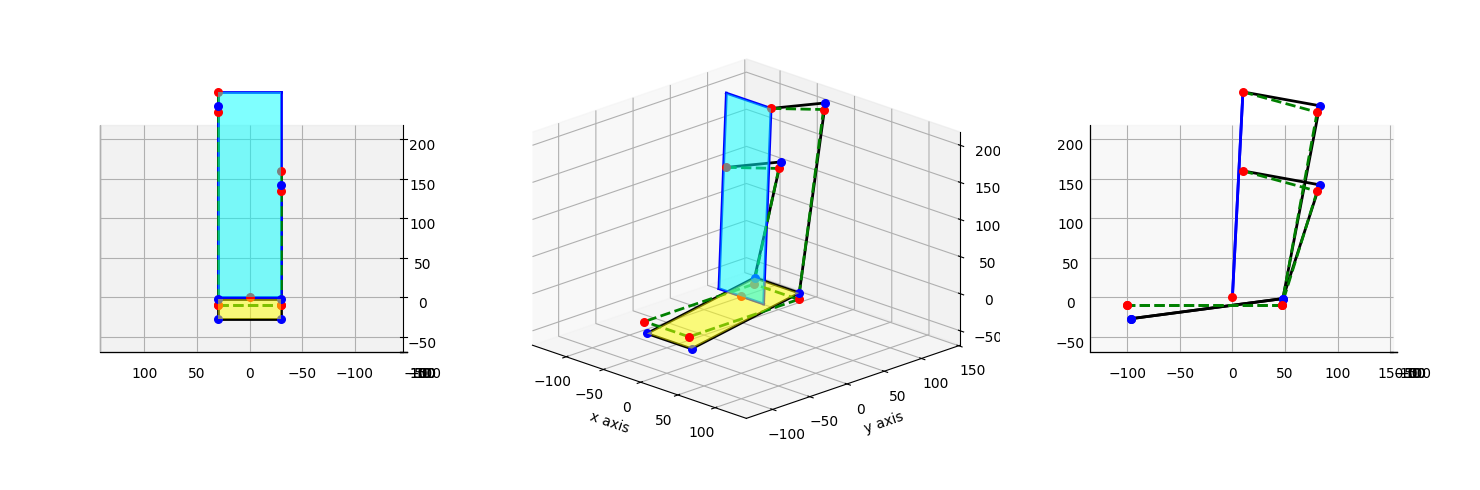

In [12]:
solve_and_plot(
    pitch_deg = 10,
    roll_deg  =  0
)